In [17]:
import pandas as pd
df=pd.read_parquet("/Users/saratramontana/Documents/test_segmentation_model/fake_train_fold_0_seed_0.parquet")

In [18]:
print(df.columns)
print(df.head())
print(type(df.iloc[0]["image"]))
print(type(df.iloc[0]["gt_mask"]))
print(len(df.iloc[0]["image"]))

Index(['clinical_case', 'item', 'frame', 'image', 'gt_mask', 'risk_class'], dtype='object')
                     clinical_case                   item  frame  \
0            -HTqLW7UkQH0F8KfsPItp  1W6gtZAwVEJIUBOGQGEpb  00000   
21           -HTqLW7UkQH0F8KfsPItp  p-1DhH_ycRLX4kMdPC1B9  00000   
13514573824  -Nd6pZbGA0TACh9Kv1Lqk  ylaa_dN9PExKFTgOtaL0D  00000   
177          -Nd6pZbGA0TACh9Kv1Lqk  ylaa_dN9PExKFTgOtaL0D  00002   
0            -Nd6pZbGA0TACh9Kv1Lqk  ylaa_dN9PExKFTgOtaL0D  00005   

                                                         image  \
0            b'\xd7BK\xecHh"m\xbd\xdf\x8bx\xc52z:\x84r\x16\...   
21           b'#\xb6\x9e\xb7\x16\xe6\xb1\x83\xdc\xedz\xa6\x...   
13514573824  b'\xe0_\x86V{\xb3\xab\xc9\xb4\xfa\xa0Lv\xac^\x...   
177          b'\xf4\xc4\tp\x11\xea~\x0c\xbd\xe3\xd8\xd7\xcf...   
0            b'F\x07\xb2d.\xe0\xd7\xdeWu\xf6\x04\xf4\xd6J\x...   

                                                       gt_mask risk_class  
0            b'(\xec\x1f3\

In [19]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import lightning as L
import segmentation_models_pytorch as smp
from lightning.pytorch.loggers import WandbLogger
import wandb
import matplotlib.pyplot as plt
from lightning.pytorch.callbacks import ModelCheckpoint

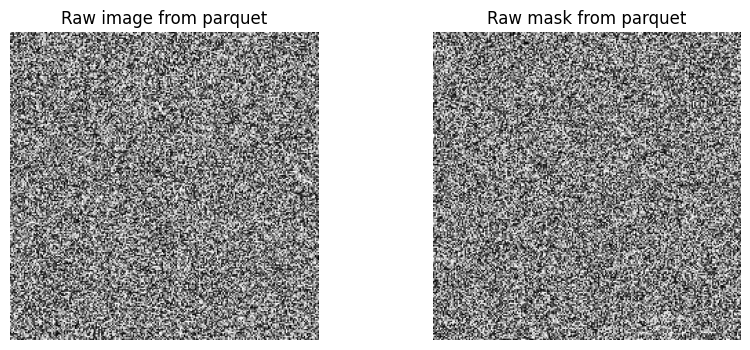

In [20]:
row = df.iloc[0] 

img = np.frombuffer(row["image"], dtype=np.uint8).reshape(224,224)
mask = np.frombuffer(row["gt_mask"], dtype=np.uint8).reshape(224,224)


plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Raw image from parquet")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Raw mask from parquet")
plt.axis("off")

plt.show()

In [21]:
#%pip install wandb

In [22]:
class MyDataset(Dataset):
    def __init__(self,df):
        self.df=df.reset_index(drop=True) 
        

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self,idx):
        row = self.df.iloc[idx]

        image = torch.tensor(np.frombuffer(row["image"], dtype=np.uint8).reshape(224,224)).float()/255 #frombuffer to convert bytes into integers from 0 to 255, then float because pytorch works with float
        image = image.unsqueeze(0)

        seg_mask = torch.tensor(np.frombuffer(row["gt_mask"], dtype=np.uint8).reshape(224,224)).float()/255
        seg_mask = (seg_mask > 0.5).float().unsqueeze(0) #First a boolean mask, then with float it becomes a binary mask and with unsqueeze I add a dimension

        cls_label = torch.tensor(1 if row["risk_class"]=="malignant" else 0)

        return image, seg_mask, cls_label
    
    



In [23]:
from sklearn.model_selection import train_test_split

# First split: train vs temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

# Second split: validation vs test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

train_dataset = MyDataset(train_df)
val_dataset = MyDataset(val_df)
test_dataset = MyDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Train samples: 1400
Validation samples: 300
Test samples: 300


In [24]:
batch = next(iter(train_loader)) 
images, seg_masks, cls_labels = batch

print(images.shape)
print(seg_masks.shape)
print(cls_labels.shape)

torch.Size([8, 1, 224, 224])
torch.Size([8, 1, 224, 224])
torch.Size([8])


In [25]:
class LitSegClsModel(L.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.save_hyperparameters() #saves the learning rate as a hyperparameter, which can be accessed later via self.hparams.lr

        aux_params = {
            "pooling": "avg",
            "dropout": 0.5,
            "activation": None,
            "classes": 2,
        }

        self.model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=1,
            classes=1,
            aux_params=aux_params
        )

        self.seg_criterion = nn.BCEWithLogitsLoss()
        self.cls_criterion = nn.CrossEntropyLoss()

    def forward(self, x): #the forward method defines how the model processes input data and produces output
        seg_logits, cls_logits = self.model(x)
        return seg_logits, cls_logits

    def training_step(self, batch, batch_idx):
        images, seg_masks, cls_labels = batch #batch is a tuple containing the input images, the corresponding segmentation masks, and the classification labels. 

        seg_logits, cls_logits = self(images) #self(images) is equivalent to self.forward(images), it calls the forward method of the model to get the segmentation and classification logits.

        seg_loss = self.seg_criterion(seg_logits, seg_masks)
        cls_loss = self.cls_criterion(cls_logits, cls_labels)

        cls_preds=torch.argmax(cls_logits,dim=1)
        cls_acc=(cls_preds==cls_labels).float().mean()

        loss = seg_loss + cls_loss

        self.log("train_loss", loss, prog_bar=True, on_step=True, on_epoch=True) #on_step=True → registra ogni batch, on_epoch=True → registra anche la media sull’epoca
        self.log("train_seg_loss", seg_loss,  on_step=True, on_epoch=True)
        self.log("train_cls_loss", cls_loss,  on_step=True, on_epoch=True)
        self.log("train_cls_acc", cls_acc, prog_bar=True, on_step=True, on_epoch=True )

        return loss

    def validation_step(self, batch, batch_idx):
        images, seg_masks, cls_labels = batch

        seg_logits, cls_logits = self(images) #seg_logits and cls_logits are the raw output of the model, they represent the unnormalized scores for each class in the segmentation and classification tasks, respectively.

        seg_loss = self.seg_criterion(seg_logits, seg_masks)
        cls_loss = self.cls_criterion(cls_logits, cls_labels)

        loss = seg_loss + cls_loss

        cls_preds = torch.argmax(cls_logits, dim=1)
        cls_acc = (cls_preds == cls_labels).float().mean()

        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_seg_loss", seg_loss, on_step=False, on_epoch=True)
        self.log("val_cls_loss", cls_loss, on_step=False, on_epoch=True)
        self.log("val_cls_acc", cls_acc, prog_bar=True, on_step=False, on_epoch=True)

        if batch_idx == 0:
            pred_masks = (torch.sigmoid(seg_logits) > 0.5).float()

            num_images = min(3, images.shape[0])
            val_examples = []

            for i in range(num_images):
                image_np = images[i].detach().cpu().squeeze().numpy() #Convert the i-th image tensor to a NumPy array and detach() stops gradient tracking, since we only need the tensor for visualization/logging
                true_mask_np = seg_masks[i].detach().cpu().squeeze().numpy().astype(np.uint8) #  uint8 (recommended format for masks in W&B)
                pred_mask_np = pred_masks[i].detach().cpu().squeeze().numpy().astype(np.uint8)

                val_examples.append(
                wandb.Image( #The wandb.Image object displays the input image together with overlay masks 
                    image_np, 
                    masks={
                        "ground_truth": {"mask_data": true_mask_np},
                        "prediction": {"mask_data": pred_mask_np},
                    },
                    caption=f"Sample {i} | true cls={cls_labels[i].item()} | pred cls={cls_preds[i].item()}"
                )
            )

            self.logger.experiment.log({
            "val_examples": val_examples,
            "global_step": self.global_step #the step number
        })

        
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr) #self.parameters() returns an iterator over the model's parameters, which are the weights and biases that the optimizer will update during training. lr=self.hparams.lr sets the learning rate for the optimizer, which controls how much the model's parameters are updated in response to the computed gradients.
        return optimizer
    
    def test_step(self, batch, batch_idx):
        images, seg_masks, cls_labels = batch

        seg_logits, cls_logits = self(images)

        seg_loss = self.seg_criterion(seg_logits, seg_masks)
        cls_loss = self.cls_criterion(cls_logits, cls_labels)
        loss = seg_loss + cls_loss

        cls_preds = torch.argmax(cls_logits, dim=1)
        cls_acc = (cls_preds == cls_labels).float().mean()

        pred_masks = (torch.sigmoid(seg_logits) > 0.5).float()
        seg_pixel_acc = (pred_masks == seg_masks).float().mean()

        self.log("test_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("test_seg_loss", seg_loss, on_step=False, on_epoch=True)
        self.log("test_cls_loss", cls_loss, on_step=False, on_epoch=True)
        self.log("test_cls_acc", cls_acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log("test_seg_pixel_acc", seg_pixel_acc, prog_bar=True, on_step=False, on_epoch=True)

        return loss
    
    

In [26]:
# model = LitSegClsModel(lr=1e-3)
# wandb_logger = WandbLogger(
#     project="test-segmentation-model",   # scegli il nome del progetto
#     name="run_prova_1"                   # nome del singolo esperimento
# )
# trainer = L.Trainer(
#     max_epochs=2,
#     limit_train_batches=5, #only 5 batches for each epoch
#     limit_val_batches=2,
#     log_every_n_steps=1,
#     logger=wandb_logger) #it means that the trainer will log the training metrics after every batch, which is useful for monitoring the training process closely
# #Now the training starts
# trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

Version with for iteration

In [27]:


# learning_rates = [1e-2, 1e-3, 1e-4]

# for lr in learning_rates:
#     wandb_logger = WandbLogger(
#         project="test-segmentation-model",
#         name=f"lr_{lr}"
#     )

#     wandb_logger.experiment.config["learning_rate"] = lr

#     model = LitSegClsModel(lr=lr)

#     trainer = L.Trainer(
#         max_epochs=2,
#         limit_train_batches=5,
#         limit_val_batches=2,
#         log_every_n_steps=1,
#         logger=wandb_logger
#     )

#     trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

#     wandb.finish()

Version with sweep 

In [28]:
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",   
    mode="min",           
    save_top_k=1
)

In [29]:
def train():
    wandb.init()

    lr = wandb.config.lr

    wandb_logger = WandbLogger(
        project="test-segmentation-model",
        log_model="all"
    )

    model = LitSegClsModel(lr=lr)

    trainer = L.Trainer(
        max_epochs=2,
        limit_train_batches=5,
        limit_val_batches=2,
        limit_test_batches=2,
        log_every_n_steps=1,
        logger=wandb_logger,
        callbacks=[checkpoint_callback]
    )

    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

    trainer.test(ckpt_path="best", dataloaders=test_loader)

    wandb.finish()

In [30]:
sweep_config = {
    "method": "grid", #here you are only saying to experiment all the 3 lr
    "metric": {"name": "val_loss", "goal": "minimize"},
    "parameters": {
        "lr": {"values": [1e-2, 1e-3, 1e-4]}
    }
}

In [31]:
sweep_id = wandb.sweep(sweep_config, project="test-segmentation-model") #It creates a true sweep in the W&B account
print(sweep_id)

Create sweep with ID: gu45tja5
Sweep URL: https://wandb.ai/sara-tramontana02-/test-segmentation-model/sweeps/gu45tja5
gu45tja5


In [32]:
wandb.agent(sweep_id, function=train, count=3) #with sweep_id you are telling which sweep to use
#in this case 3 runs since I have 3 lr

wandb: Agent Starting Run: 1u7twogd with config:
wandb: 	lr: 0.01
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/saratramontana/.netrc.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/lightning/pytorch/loggers/wandb.py:400: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ Unet              │ 24.4 M │ train │     0 │
│ 1 │ seg_criterion │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 2 │ cls_criterion │ CrossEntropyLoss  │      0 │ train │     0 │
└───┴───────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 24.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.4 M                                                                                               
Total estimated model params size (MB): 97                                                                         
Modules in train mode: 197                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

wandb: WARNING Config item 'lr' was locked by 'sweep' (ignored update).


...

/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/dat
a_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=2` reached.


Restoring states from the checkpoint path at ./test-segmentation-model/1u7twogd/checkpoints/epoch=1-step=10.ckpt
wandb: WARNING Config item 'lr' was locked by 'sweep' (ignored update).
Loaded model weights from the checkpoint at ./test-segmentation-model/1u7twogd/checkpoints/epoch=1-step=10.ckpt
/Users/saratramontana/anaconda3/envs/test-seg/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_cls_acc        │           0.375           │
│       test_cls_loss       │    0.8513936996459961     │
│         test_loss         │    1.6111187934875488     │
│       test_seg_loss       │    0.7597250938415527     │
│    test_seg_pixel_acc     │    0.5003387928009033     │
└───────────────────────────┴───────────────────────────┘

epoch,▁▁▁▁▁▁▁▅▅▅▅▅▅▅█
global_step,▁▅█
test_cls_acc,▁
test_cls_loss,▁
test_loss,▁
test_seg_loss,▁
test_seg_pixel_acc,▁
train_cls_acc_epoch,▁█
train_cls_acc_step,▆▂▁▃▆█▅▁▅▃
train_cls_loss_epoch,█▁
+10,...
